# 04 · Nonstationary univariate analysis

Follow the saved Brays Bayou LP-III alternatives to compare how location and scale change through time.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Seven structural alternatives
Begin with the constant model, then compare linear, logistic and step changes. The three two-part names represent the saved combinations
of location and scale links. These are alternative explanations of a changing flood record; adding flexibility does not establish the cause of a trend.

In [2]:
PROJECT = "nsffa-brays-bayou-texas"
names = next(g["names"] for g in json.loads((ROOT / "curriculum-cases.json").read_text()) if g["notebook"] == "04")
cases = [saved_case(PROJECT, name, run=RUN_ANALYSES) for name in names]
project = load_project(PROJECT)
display(input_inventory(project))
display(cases[1].settings)
display(trend_ownership(project, names[:-1]))
display(case_metrics(cases[:-1], comparison_scope="Comparable fitted alternatives: same Brays Bayou response, observations, and likelihood."))
display(case_metrics([cases[-1]]))
display(case_provenance(cases))

,Input,Unit,Method,Exact,Uncertain,Interval,Threshold,Flagged low floods
0,USGS 08075000 Brays Bayou,Peak Discharge (cfs),USGSPeakDischarge,90,0,0,1,0
1,USGS 08075000 Brays Bayou - Metric,Peak Discharge (cms),Manual,90,0,0,1,0
2,USGS 08075000 Brays Bayou_copy,Peak Discharge (cfs),USGSPeakDischarge,90,0,0,1,0
3,USGS 08075000 Brays Bayou_copy_copy,Peak Discharge (cfs),USGSPeakDischarge,90,0,0,1,0


,Setting,Saved choice
0,Analysis,UnivariateAnalysis
1,InputData,USGS 08075000 Brays Bayou - Metric
2,BayesianAnalysis.Type,DEMCzs
3,BayesianAnalysis.NumberOfChains,8
4,BayesianAnalysis.ThinningInterval,40
5,BayesianAnalysis.WarmupIterations,1750
6,BayesianAnalysis.Iterations,3500
7,BayesianAnalysis.UseSimulationDefaults,True
8,BayesianAnalysis.PRNGSeed,12345
9,BayesianAnalysis.CredibleIntervalWidth,0.90000000000000002


,Alternative,Mean (of log),Std Dev (of log),Skew (of log)
0,NSFFA - Constant,Constant,Constant,Constant
1,NSFFA - Linear,Linear,Constant,Constant
2,NSFFA - Logistic,Logistic,Constant,Constant
3,NSFFA - Step,StepFunction,Constant,Constant
4,NSFFA - Linear - Logistic,Linear,Logistic,Constant
5,NSFFA - Logistic - Logistic,Logistic,Logistic,Constant
6,NSFFA - Step - Logistic,StepFunction,Logistic,Constant


,Analysis,Input / response,Analysis type,AIC,BIC,DIC,RMSE,Metric note,Comparison scope
0,NSFFA - Constant,USGS 08075000 Brays Bayou - Metric,UnivariateAnalysis,1228.713757,1236.406802,1228.346863,22.833833,,Comparable fitted alternatives: same Brays Bay...
1,NSFFA - Linear,USGS 08075000 Brays Bayou - Metric,UnivariateAnalysis,1180.744535,1191.001928,1180.365434,536.471217,,Comparable fitted alternatives: same Brays Bay...
2,NSFFA - Logistic,USGS 08075000 Brays Bayou - Metric,UnivariateAnalysis,1179.607711,1189.865104,1178.943038,604.945751,,Comparable fitted alternatives: same Brays Bay...
3,NSFFA - Step,USGS 08075000 Brays Bayou - Metric,UnivariateAnalysis,1157.736996,1170.558737,1158.119559,126.429252,,Comparable fitted alternatives: same Brays Bay...
4,NSFFA - Linear - Logistic,USGS 08075000 Brays Bayou - Metric,UnivariateAnalysis,1173.007658,1185.829399,1172.296182,408.772465,,Comparable fitted alternatives: same Brays Bay...
5,NSFFA - Logistic - Logistic,USGS 08075000 Brays Bayou - Metric,UnivariateAnalysis,1167.430185,1180.251926,1161.830991,346.347628,,Comparable fitted alternatives: same Brays Bay...
6,NSFFA - Step - Logistic,USGS 08075000 Brays Bayou - Metric,UnivariateAnalysis,1154.437524,1169.823613,1154.834404,163.574875,,Comparable fitted alternatives: same Brays Bay...


,Analysis,Input / response,Analysis type,AIC,BIC,DIC,RMSE,Metric note,Comparison scope
0,Bayesian Model Average,USGS 08075000 Brays Bayou - Metric,CompositeAnalysis,<NA>,<NA>,<NA>,<NA>,N/A: composite result does not define these fi...,Descriptive only — rows may use different resp...


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,NSFFA - Constant,saved-app,sha256:9c513e3b1dbe,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
1,NSFFA - Linear,saved-app,sha256:9c513e3b1dbe,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
2,NSFFA - Logistic,saved-app,sha256:9c513e3b1dbe,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
3,NSFFA - Step,saved-app,sha256:9c513e3b1dbe,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
4,NSFFA - Linear - Logistic,saved-app,sha256:9c513e3b1dbe,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
5,NSFFA - Logistic - Logistic,saved-app,sha256:9c513e3b1dbe,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
6,NSFFA - Step - Logistic,saved-app,sha256:9c513e3b1dbe,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
7,Bayesian Model Average,saved-app,sha256:9c513e3b1dbe,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt


## Chronology and conditional frequency
The chronology view follows the app's configured nonstationary conditions and probability outputs.
A frequency curve under changing parameters must be interpreted at its specified condition; it is not one timeless return-period curve for the whole record.

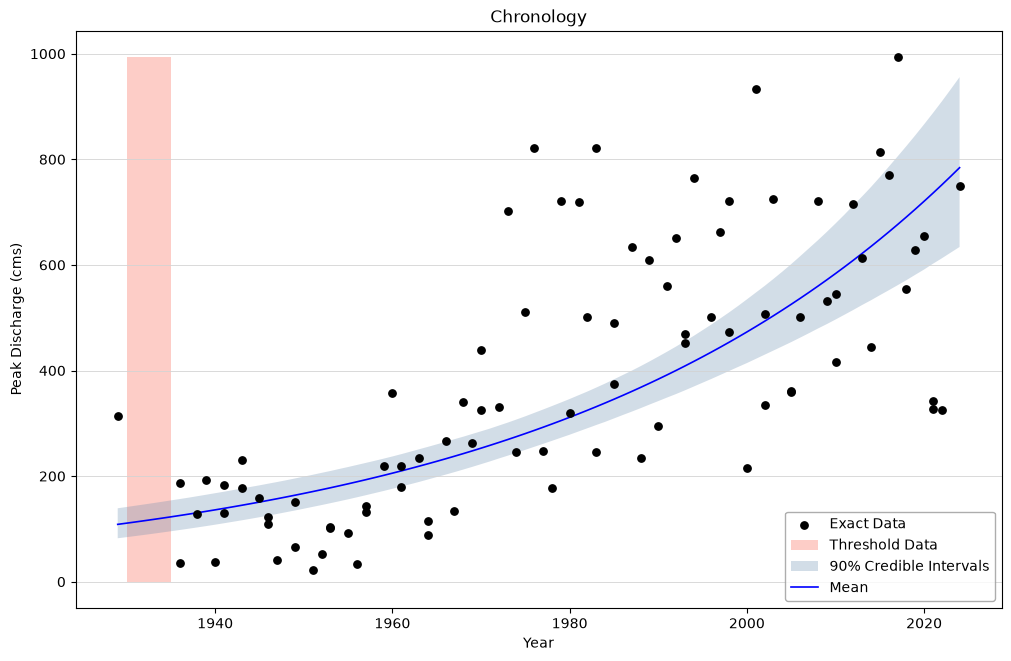

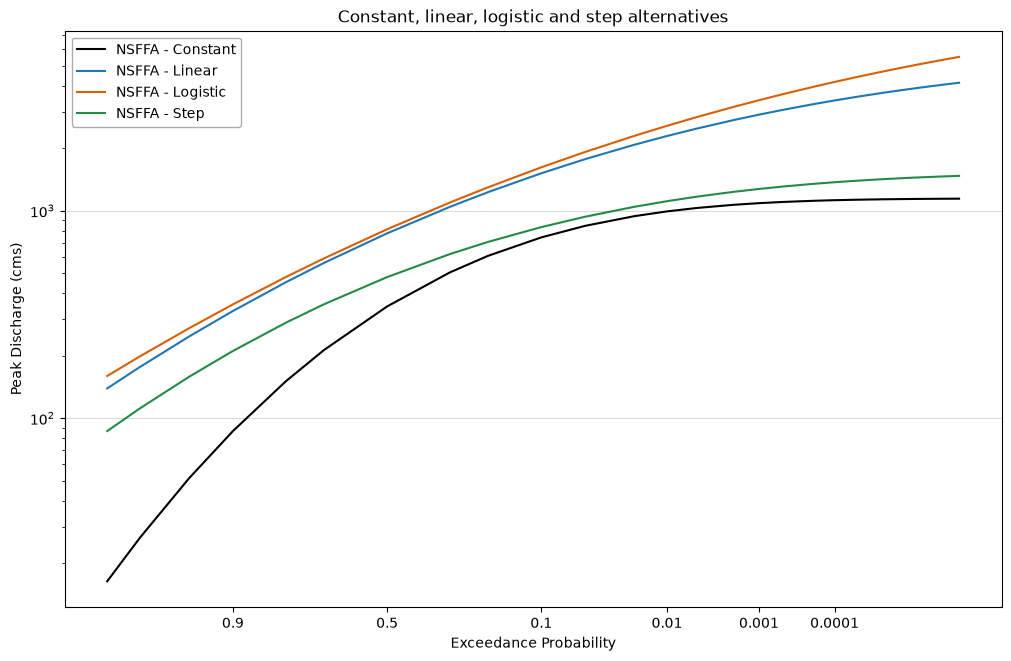

In [3]:
cases[1].show("chronology")
compare_frequency(cases[:4], "Constant, linear, logistic and step alternatives")

## Model averaging
`Bayesian Model Average` is the app's DIC-weighted composite of the saved alternatives.
Its uncertainty reflects those chosen models and weights; it does not include every possible future change in the watershed.
The saved component curves are evaluated at parameter time index 2024. Zero-valued persisted composite fit metrics are placeholders and display as N/A.

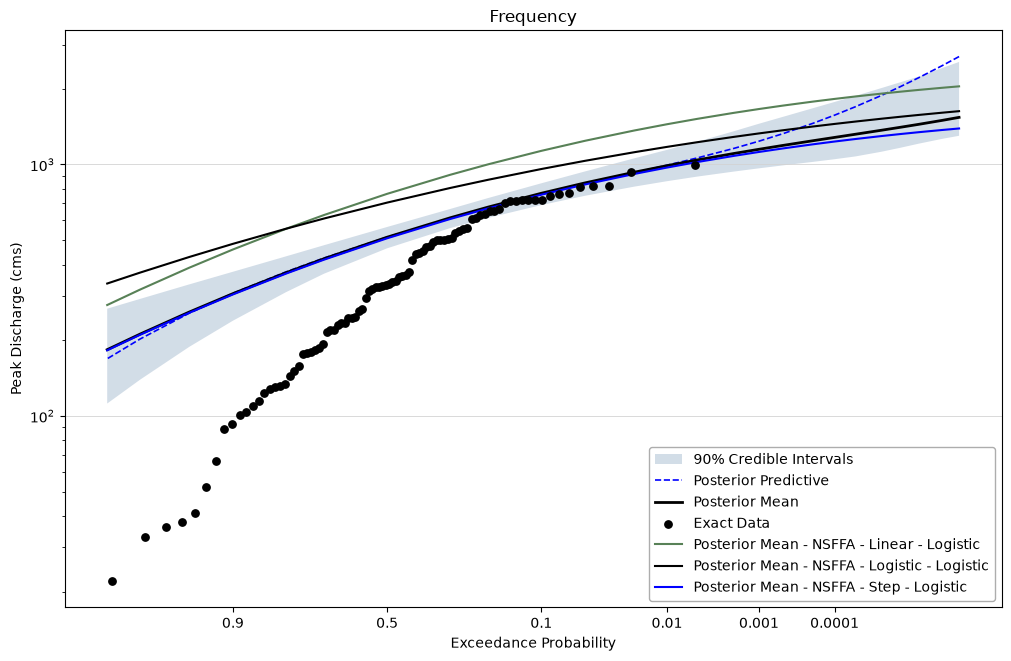

,Setting,Saved choice
0,Analysis,CompositeAnalysis
1,InputData,USGS 08075000 Brays Bayou - Metric
2,Dependencies,NSFFA - Linear - Logistic; NSFFA - Logistic - ...


,Alternative,Weight,Method
0,NSFFA - Linear - Logistic,0.000157,DIC
1,NSFFA - Logistic - Logistic,0.029356,DIC
2,NSFFA - Step - Logistic,0.970487,DIC


,Evaluation year,Weight method
0,2024,DIC


In [4]:
cases[-1].show("frequency")
display(cases[-1].settings)
display(composite_weights(project, "Bayesian Model Average"))
display(pd.DataFrame({"Evaluation year": [int(cases[0].data["settings"]["Model.ParameterTimeIndex"])],
                      "Weight method": ["DIC"]}))